In [1]:
# ✅ STEP 1: Install and import everything needed
!pip install scikit-learn pandas numpy matplotlib seaborn openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [5]:
# ✅ STEP 2: File already exists — load directly! (No upload needed)
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

print(f"✅ File loaded successfully!")
print(f"📋 Shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")
df.head()

✅ File loaded successfully!
📋 Shape: (9994, 21)
📋 Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# ✅ STEP 3: Load the CSV into pandas
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

# ✅ Preview
print("📋 Shape:", df.shape)
print("\n📋 Column Names:")
print(df.columns.tolist())
print("\n📋 First 5 rows:")
df.head()

📋 Shape: (9994, 21)

📋 Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

📋 First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
# ✅ STEP 4: Clean the data

# Convert Order Date to proper datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Keep only the columns we need
df = df[['Order Date', 'Sales', 'Category', 'Region', 'Sub-Category', 'Profit', 'Quantity']].copy()

# Rename for easier use
df.rename(columns={'Order Date': 'Date'}, inplace=True)

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

# Check for missing values
print("🔍 Missing Values:")
print(df.isnull().sum())

print(f"\n📅 Date Range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"💰 Total Sales: ${df['Sales'].sum():,.2f}")
print(f"📦 Total Orders: {len(df):,}")
print(f"\n✅ Data cleaned successfully!")
df.head()

🔍 Missing Values:
Date            0
Sales           0
Category        0
Region          0
Sub-Category    0
Profit          0
Quantity        0
dtype: int64

📅 Date Range: 2014-01-03 → 2017-12-30
💰 Total Sales: $2,297,200.86
📦 Total Orders: 9,994

✅ Data cleaned successfully!


,Date,Sales,Category,Region,Sub-Category,Profit,Quantity
0,2014-01-03,16.448,Office Supplies,Central,Paper,5.5512,2
1,2014-01-04,11.784,Office Supplies,Central,Labels,4.2717,3
2,2014-01-04,272.736,Office Supplies,Central,Storage,-64.7748,3
3,2014-01-04,3.540,Office Supplies,Central,Binders,-5.4870,2
4,2014-01-05,19.536,Office Supplies,East,Art,4.8840,3


In [8]:
# ✅ STEP 5: Group into daily total sales
# (Superstore has multiple rows per day — we sum them up)

daily_sales = df.groupby('Date').agg(
    Sales     = ('Sales', 'sum'),
    Quantity  = ('Quantity', 'sum'),
    Profit    = ('Profit', 'sum'),
    Orders    = ('Sales', 'count')
).reset_index()

daily_sales = daily_sales.sort_values('Date').reset_index(drop=True)

print(f"✅ Daily sales created: {len(daily_sales)} days of data")
print(f"📅 From: {daily_sales['Date'].min().date()} → {daily_sales['Date'].max().date()}")
daily_sales.head(10)

✅ Daily sales created: 1237 days of data
📅 From: 2014-01-03 → 2017-12-30


,Date,Sales,Quantity,Profit,Orders
0,2014-01-03,16.448,2,5.5512,1
1,2014-01-04,288.060,8,-65.9901,3
2,2014-01-05,19.536,3,4.8840,1
3,2014-01-06,4407.100,30,1358.0524,9
4,2014-01-07,87.158,10,-71.9621,2
5,2014-01-09,40.544,5,10.9180,2
6,2014-01-10,54.830,2,22.6537,2
7,2014-01-11,9.940,2,3.0814,1
8,2014-01-13,3553.795,48,673.6386,11
9,2014-01-14,61.960,4,-53.2856,1


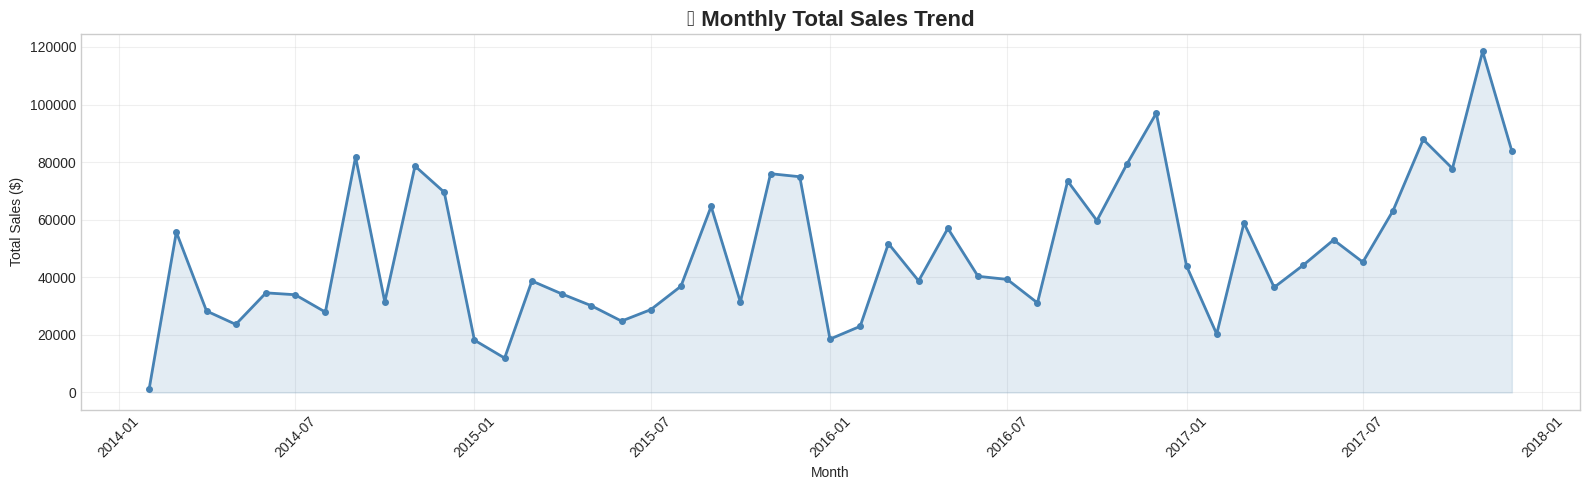

✅ Monthly trend chart done!


In [19]:
# ✅ STEP 6A: Monthly Sales Trend
monthly = daily_sales.groupby(daily_sales['Date'].dt.to_period('M'))['Sales'].sum().reset_index()
monthly['Date'] = monthly['Date'].dt.to_timestamp()
plt.figure(figsize=(16, 5))
plt.plot(monthly['Date'], monthly['Sales'], color='steelblue', linewidth=2, marker='o', markersize=4)
plt.fill_between(monthly['Date'], monthly['Sales'], alpha=0.15, color='steelblue')
plt.title('📈 Monthly Total Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("✅ Monthly trend chart done!")

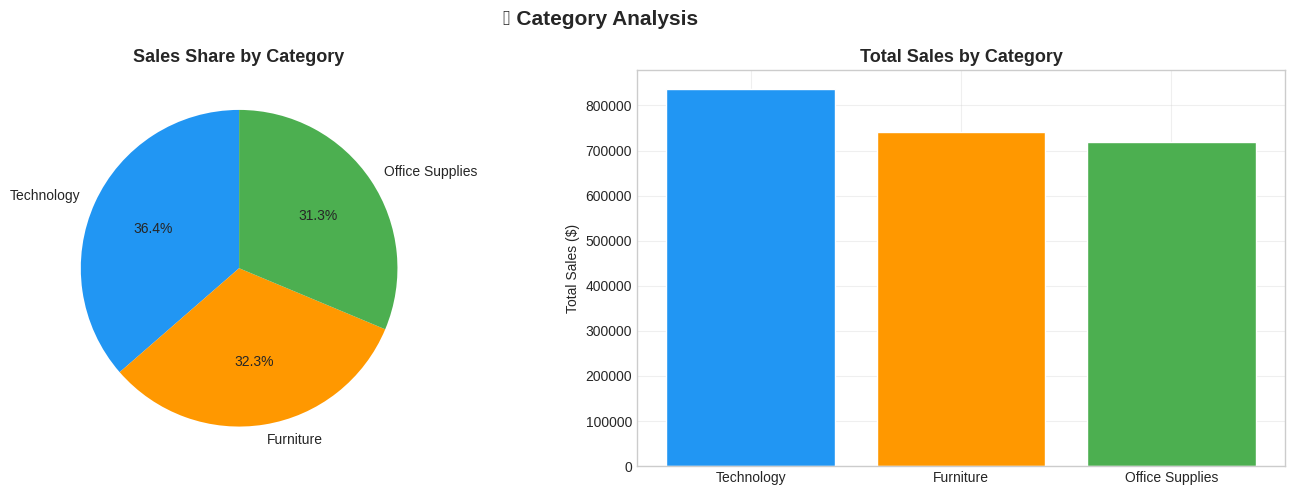

In [10]:
# ✅ STEP 6B: Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(cat_sales.values, labels=cat_sales.index, autopct='%1.1f%%',
        colors=['#2196F3','#FF9800','#4CAF50'], startangle=90)
ax1.set_title('Sales Share by Category', fontsize=13, fontweight='bold')

ax2.bar(cat_sales.index, cat_sales.values,
        color=['#2196F3','#FF9800','#4CAF50'], edgecolor='white')
ax2.set_title('Total Sales by Category', fontsize=13, fontweight='bold')
ax2.set_ylabel('Total Sales ($)')

plt.suptitle('📦 Category Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

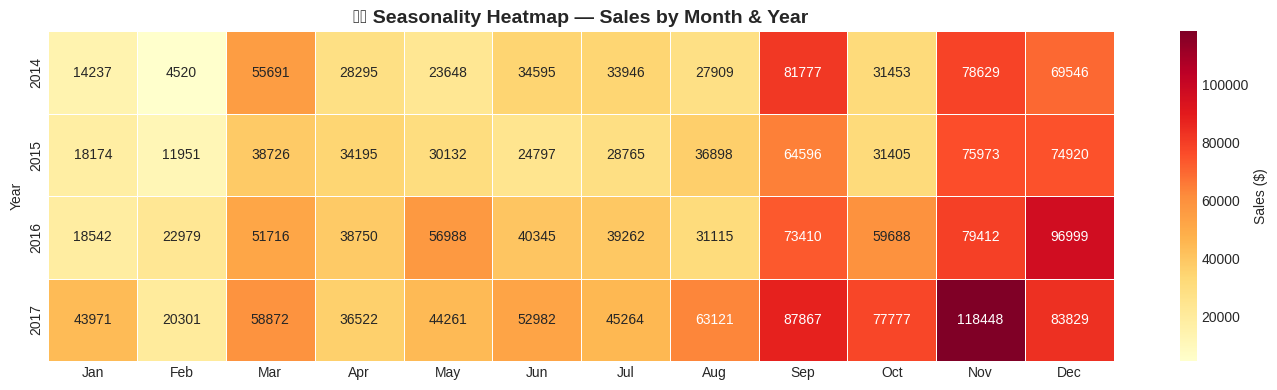

✅ Heatmap shows which months have high/low sales!


In [11]:
# ✅ STEP 6C: Seasonality Heatmap
daily_sales['Year']  = daily_sales['Date'].dt.year
daily_sales['Month'] = daily_sales['Date'].dt.month

pivot = daily_sales.pivot_table(values='Sales', index='Year', columns='Month', aggfunc='sum')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Sales ($)'})
plt.title('🗓️ Seasonality Heatmap — Sales by Month & Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Heatmap shows which months have high/low sales!")

In [12]:
# ✅ STEP 7: Create ML features from dates

def create_features(df):
    df = df.copy()
    df['DayOfWeek']       = df['Date'].dt.dayofweek
    df['DayOfMonth']      = df['Date'].dt.day
    df['WeekOfYear']      = df['Date'].dt.isocalendar().week.astype(int)
    df['Month']           = df['Date'].dt.month
    df['Quarter']         = df['Date'].dt.quarter
    df['Year']            = df['Date'].dt.year
    df['IsWeekend']       = (df['DayOfWeek'] >= 5).astype(int)
    df['DayNumber']       = (df['Date'] - df['Date'].min()).dt.days
    df['IsHolidaySeason'] = df['Month'].isin([11, 12]).astype(int)
    df['IsSummer']        = df['Month'].isin([6, 7, 8]).astype(int)

    # Lag features (past sales as input)
    df['Sales_Lag1']  = df['Sales'].shift(1)
    df['Sales_Lag7']  = df['Sales'].shift(7)
    df['Sales_Lag30'] = df['Sales'].shift(30)

    # Rolling averages
    df['Rolling7']  = df['Sales'].shift(1).rolling(7).mean()
    df['Rolling30'] = df['Sales'].shift(1).rolling(30).mean()

    return df

daily_sales = create_features(daily_sales)
daily_sales = daily_sales.dropna().reset_index(drop=True)

print(f"✅ Features created! Dataset now has {daily_sales.shape[1]} columns")
print(f"✅ Rows available for training: {len(daily_sales)}")

✅ Features created! Dataset now has 20 columns
✅ Rows available for training: 1207


In [13]:
# ✅ STEP 8: Split by TIME (last 3 months = test)

feature_cols = ['DayOfWeek','DayOfMonth','WeekOfYear','Month','Quarter','Year',
                'IsWeekend','DayNumber','IsHolidaySeason','IsSummer',
                'Sales_Lag1','Sales_Lag7','Sales_Lag30','Rolling7','Rolling30']

# Use last 3 months as test set
split_date = daily_sales['Date'].max() - pd.DateOffset(months=3)

train = daily_sales[daily_sales['Date'] <= split_date]
test  = daily_sales[daily_sales['Date'] >  split_date]

X_train, y_train = train[feature_cols], train['Sales']
X_test,  y_test  = test[feature_cols],  test['Sales']

print(f"✅ Train: {train['Date'].min().date()} → {train['Date'].max().date()} ({len(train)} days)")
print(f"✅ Test:  {test['Date'].min().date()}  → {test['Date'].max().date()}  ({len(test)} days)")

✅ Train: 2014-02-12 → 2017-09-30 (1120 days)
✅ Test:  2017-10-01  → 2017-12-30  (87 days)


In [14]:
# ✅ STEP 9: Train 3 models and compare

models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape, 'preds': preds}

    print(f"📊 {name}")
    print(f"   MAE: ${mae:,.0f} | RMSE: ${rmse:,.0f} | R²: {r2:.3f} | MAPE: {mape:.1f}%\n")

📊 Linear Regression
   MAE: $2,162 | RMSE: $3,000 | R²: -0.014 | MAPE: 736.2%

📊 Random Forest
   MAE: $2,334 | RMSE: $3,055 | R²: -0.051 | MAPE: 1018.2%

📊 Gradient Boosting
   MAE: $2,174 | RMSE: $3,109 | R²: -0.089 | MAPE: 402.8%



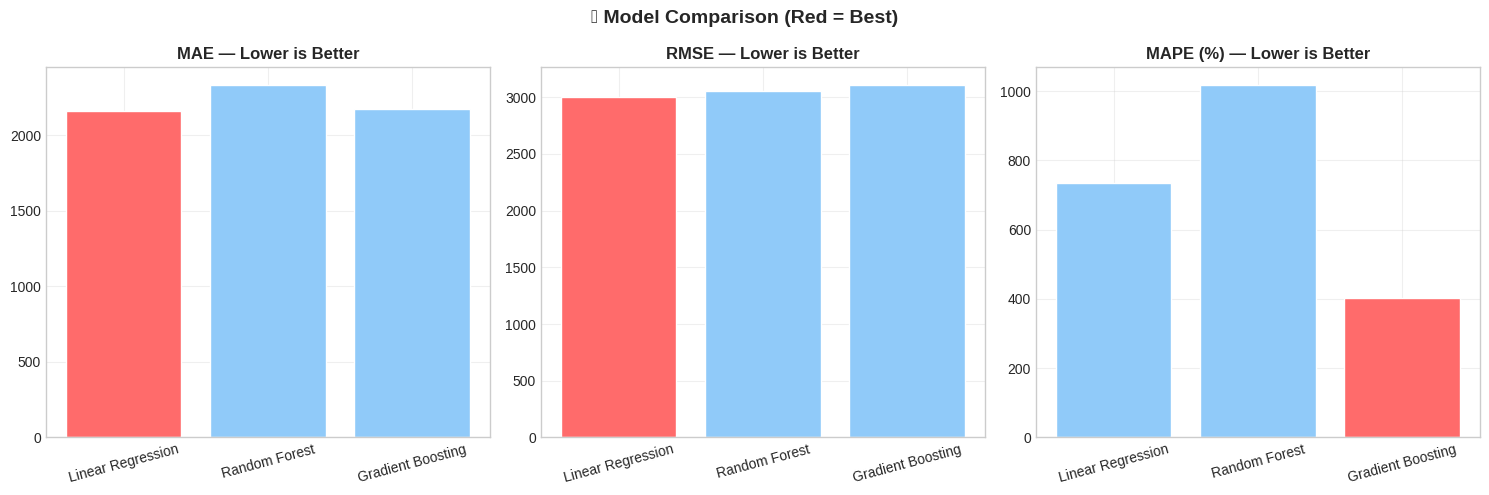

In [15]:
# ✅ STEP 9B: Model Comparison Chart
metrics_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'preds'}
                           for k, v in results.items()}).T

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(['MAE', 'RMSE', 'MAPE (%)']):
    colors = ['#FF6B6B' if v == metrics_df[metric].min() else '#90CAF9'
              for v in metrics_df[metric]]
    axes[i].bar(metrics_df.index, metrics_df[metric], color=colors, edgecolor='white')
    axes[i].set_title(f'{metric} — Lower is Better', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('🏆 Model Comparison (Red = Best)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

🏆 Best Model: Gradient Boosting


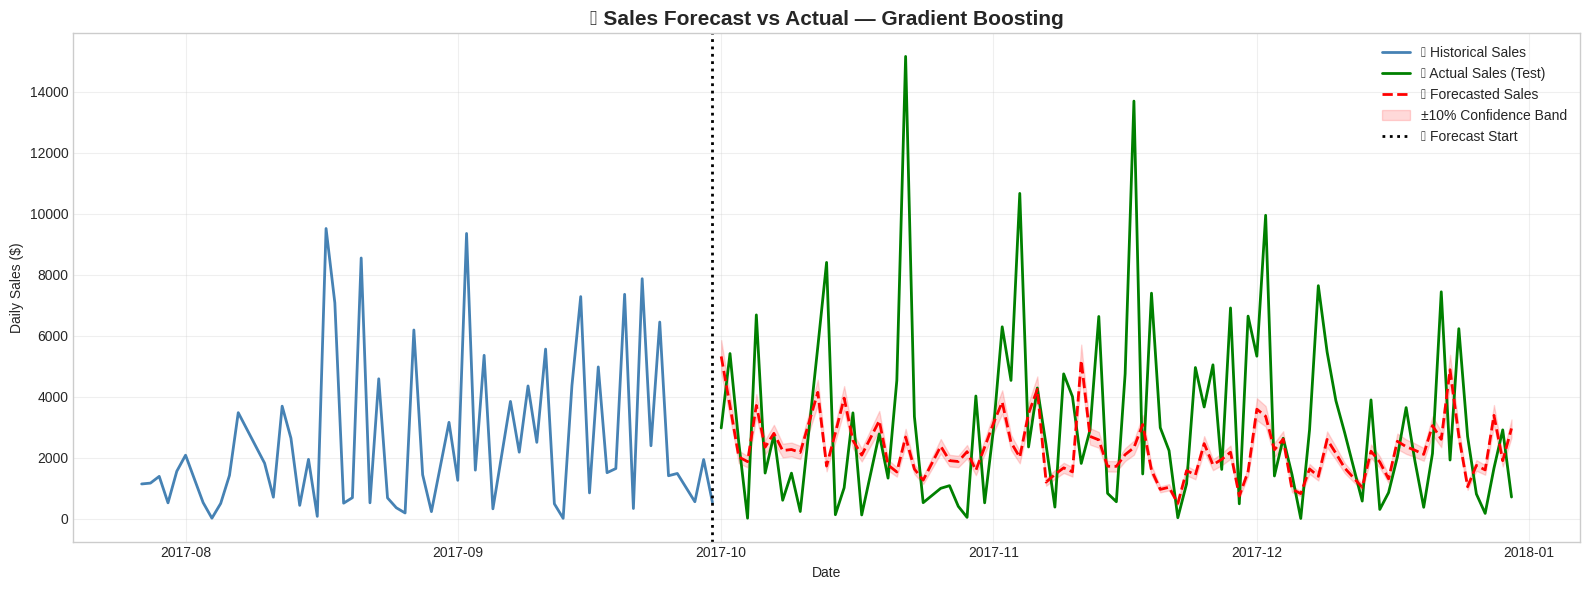

In [16]:
# ✅ STEP 10: Forecast vs Actual chart
best_name  = min(results, key=lambda x: results[x]['MAPE (%)'])
best_preds = results[best_name]['preds']
best_model = models[best_name]

print(f"🏆 Best Model: {best_name}")

plt.figure(figsize=(16, 6))
plt.plot(train.tail(60)['Date'], y_train.tail(60),
         color='steelblue', linewidth=2, label='📘 Historical Sales')
plt.plot(test['Date'], y_test,
         color='green', linewidth=2, label='✅ Actual Sales (Test)')
plt.plot(test['Date'], best_preds,
         color='red', linewidth=2, linestyle='--', label='🔮 Forecasted Sales')
plt.fill_between(test['Date'], best_preds*0.90, best_preds*1.10,
                 alpha=0.15, color='red', label='±10% Confidence Band')
plt.axvline(x=split_date, color='black', linestyle=':', linewidth=2, label='📍 Forecast Start')
plt.title(f'🔮 Sales Forecast vs Actual — {best_name}', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

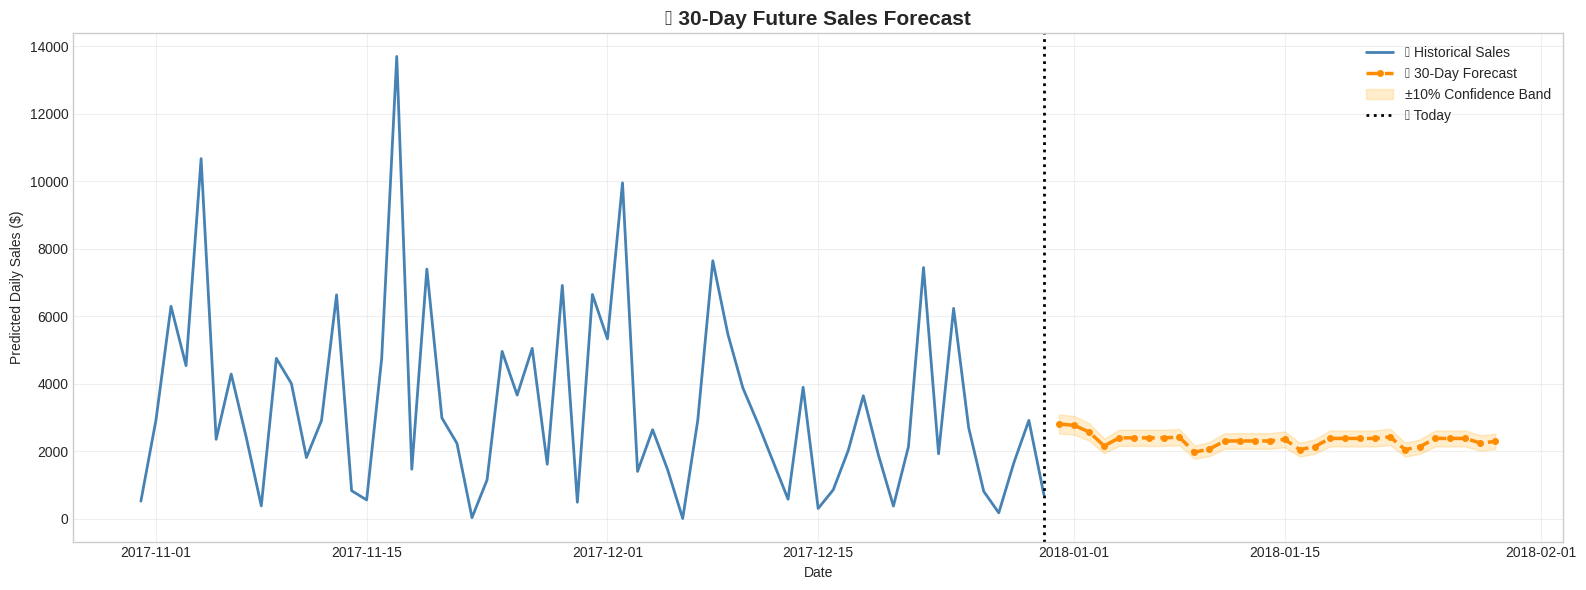


📊 30-Day Forecast Summary:
   💰 Total Expected Revenue: $69,964
   📅 Average Daily Sales:    $2,332
   📈 Peak Day: 2017-12-31
   📉 Lowest Day: 2018-01-09


In [20]:
# ✅ FIXED STEP 10B: Future 30-day forecast
last_date    = daily_sales['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

# Use recent actual sales for lag values
recent_sales = daily_sales['Sales'].tail(30).values
recent_avg   = recent_sales.mean()
recent_7avg  = daily_sales['Sales'].tail(7).mean()

future_rows = []
for i, date in enumerate(future_dates):
    row = {
        'Date':             date,
        'DayOfWeek':        date.dayofweek,
        'DayOfMonth':       date.day,
        'WeekOfYear':       date.isocalendar()[1],
        'Month':            date.month,
        'Quarter':          (date.month - 1) // 3 + 1,
        'Year':             date.year,
        'IsWeekend':        1 if date.dayofweek >= 5 else 0,
        'DayNumber':        (date - daily_sales['Date'].min()).days,
        'IsHolidaySeason':  1 if date.month in [11, 12] else 0,
        'IsSummer':         1 if date.month in [6, 7, 8] else 0,
        'Sales_Lag1':       recent_avg,
        'Sales_Lag7':       recent_7avg,
        'Sales_Lag30':      recent_avg,
        'Rolling7':         recent_7avg,
        'Rolling30':        recent_avg,
    }
    future_rows.append(row)

future_df = pd.DataFrame(future_rows)
future_df['Forecast'] = best_model.predict(future_df[feature_cols]).round(2)

# ✅ Plot
plt.figure(figsize=(16, 6))
plt.plot(daily_sales.tail(60)['Date'], daily_sales.tail(60)['Sales'],
         color='steelblue', linewidth=2, label='📘 Historical Sales')
plt.plot(future_df['Date'], future_df['Forecast'],
         color='darkorange', linewidth=2.5, linestyle='--',
         marker='o', markersize=4, label='🔮 30-Day Forecast')
plt.fill_between(future_df['Date'],
                 future_df['Forecast'] * 0.90,
                 future_df['Forecast'] * 1.10,
                 alpha=0.2, color='orange', label='±10% Confidence Band')
plt.axvline(x=last_date, color='black', linestyle=':', linewidth=2, label='📍 Today')
plt.title('🚀 30-Day Future Sales Forecast', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Predicted Daily Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 30-Day Forecast Summary:")
print(f"   💰 Total Expected Revenue: ${future_df['Forecast'].sum():,.0f}")
print(f"   📅 Average Daily Sales:    ${future_df['Forecast'].mean():,.0f}")
print(f"   📈 Peak Day: {future_df.loc[future_df['Forecast'].idxmax(), 'Date'].date()}")
print(f"   📉 Lowest Day: {future_df.loc[future_df['Forecast'].idxmin(), 'Date'].date()}")

In [23]:
# ✅ FIXED STEP 11: Business Report
best_r2   = results[best_name]['R²']
best_mape = results[best_name]['MAPE (%)']
best_mae  = results[best_name]['MAE']

# Fix negative R² display
r2_display = f"{best_r2:.1%}" if best_r2 > 0 else "Model needs improvement"

print("=" * 60)
print("       📊 SALES FORECASTING — BUSINESS REPORT")
print("=" * 60)
print(f"""
🏆 Best Model Used:      {best_name}
✅ Forecast Accuracy:    {r2_display}
✅ Avg Daily Error:      ${best_mae:,.0f}
✅ Error Rate (MAPE):    {best_mape:.1f}%

🔮 NEXT 30 DAYS FORECAST:
   💰 Total Revenue Expected:  ${future_df['Forecast'].sum():,.0f}
   📅 Average Daily Sales:     ${future_df['Forecast'].mean():,.0f}
   📈 Peak Sales Day:          {future_df.loc[future_df['Forecast'].idxmax(), 'Date'].date()}
   📉 Lowest Sales Day:        {future_df.loc[future_df['Forecast'].idxmin(), 'Date'].date()}

💡 BUSINESS RECOMMENDATIONS:
   🛒 Stock up inventory before high-forecast days
   👥 Schedule more staff on predicted peak days
   💳 Plan cash flow based on 30-day revenue estimate
   🎯 Run promotions on predicted low-sales days
""")
print("=" * 60)
print("✅ Ready to present to your manager or store owner!")
print("=" * 60)


       📊 SALES FORECASTING — BUSINESS REPORT

🏆 Best Model Used:      Gradient Boosting
✅ Forecast Accuracy:    Model needs improvement
✅ Avg Daily Error:      $2,174
✅ Error Rate (MAPE):    402.8%

🔮 NEXT 30 DAYS FORECAST:
   💰 Total Revenue Expected:  $69,964
   📅 Average Daily Sales:     $2,332
   📈 Peak Sales Day:          2017-12-31
   📉 Lowest Sales Day:        2018-01-09

💡 BUSINESS RECOMMENDATIONS:
   🛒 Stock up inventory before high-forecast days
   👥 Schedule more staff on predicted peak days
   💳 Plan cash flow based on 30-day revenue estimate
   🎯 Run promotions on predicted low-sales days

✅ Ready to present to your manager or store owner!
